# MLPClasifier

|                |   |
:----------------|---|
| **Nombre**     David Alejandro Rangel Rodríguez|   |
| **Fecha**     26 de marzo del 2026 |   |
| **Expediente*756203* |   |

In [28]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

data = pd.read_csv('Heart Prediction Quantum Dataset.csv')
data.head()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
0,68,1,105,191,107,8.362241,1
1,58,0,97,249,89,9.249002,0
2,44,0,93,190,82,7.942542,1
3,72,1,93,183,101,6.495155,1
4,37,0,145,166,103,7.653900,1


In [29]:
data.tail()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
495,34,0,126,292,116,9.303403,0
496,41,0,164,248,114,9.067889,0
497,45,1,159,175,75,8.718708,0
498,55,0,107,157,101,7.337650,1
499,55,0,174,249,89,10.492950,0


In [30]:
data.describe()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,54.864000,0.468000,132.874000,221.50000,88.766000,8.317407,0.600000
std,14.315004,0.499475,26.418516,43.86363,17.417289,0.919629,0.490389
min,30.000000,0.000000,90.000000,150.00000,60.000000,6.164692,0.000000
25%,43.000000,0.000000,111.000000,183.75000,73.000000,7.675779,0.000000
50%,55.000000,0.000000,132.000000,221.00000,89.000000,8.323064,1.000000
75%,66.250000,1.000000,155.000000,258.00000,104.000000,8.935999,1.000000
max,79.000000,1.000000,179.000000,299.00000,119.000000,10.784886,1.000000


In [31]:
data.isnull().sum()

Age                      0
Gender                   0
BloodPressure            0
Cholesterol              0
HeartRate                0
QuantumPatternFeature    0
HeartDisease             0
dtype: int64

In [32]:
data.corr()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
Age,1.000000,-0.017147,0.031548,-0.014161,0.023712,-0.378599,0.258298
Gender,-0.017147,1.000000,-0.039109,0.025246,-0.010883,0.010276,-0.011454
BloodPressure,0.031548,-0.039109,1.000000,-0.037793,-0.070828,0.105652,-0.116973
Cholesterol,-0.014161,0.025246,-0.037793,1.000000,0.014156,0.549047,-0.423530
HeartRate,0.023712,-0.010883,-0.070828,0.014156,1.000000,0.113533,-0.102720
QuantumPatternFeature,-0.378599,0.010276,0.105652,0.549047,0.113533,1.000000,-0.775160
HeartDisease,0.258298,-0.011454,-0.116973,-0.423530,-0.102720,-0.775160,1.000000


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'Cholesterol'}>,
        <Axes: title={'center': 'HeartRate'}>,
        <Axes: title={'center': 'QuantumPatternFeature'}>],
       [<Axes: title={'center': 'HeartDisease'}>, <Axes: >, <Axes: >]],
      dtype=object)

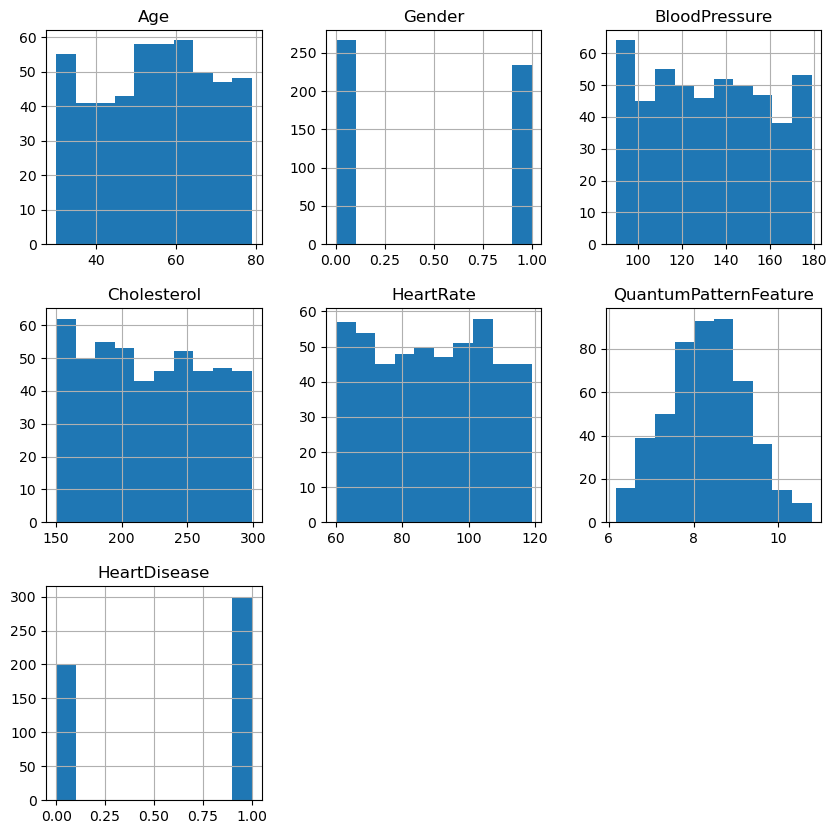

In [33]:
data.hist(figsize=(10,10))

## Definimos X y Y

In [34]:
Y = data['HeartDisease']
X = data.drop(['HeartDisease','QuantumPatternFeature'], axis=1)

X_numericas = ['Age','BloodPressure','Cholesterol','HeartRate']
X_categoricas = ['Gender']

## Escalamiento

In [35]:
from sklearn.preprocessing import StandardScaler
num_transformer=StandardScaler()

In [36]:
preprocessor = ColumnTransformer(
    transformers=[('num', num_transformer, X_numericas)])

## Pipeline

In [37]:
model=MLPClassifier(hidden_layer_sizes=([5,10]),random_state=42)
model

MLPClassifier(hidden_layer_sizes=[5, 10], random_state=42)

In [38]:
pipeline = Pipeline(steps=[('procesador', preprocessor),('modelo',model)])

In [41]:
pipeline.fit(X,Y)

C:\Users\range\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('procesador',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'BloodPressure',
                                                   'Cholesterol',
                                                   'HeartRate'])])),
                ('modelo',
                 MLPClassifier(hidden_layer_sizes=[5, 10], random_state=42))])

In [42]:
pipeline.score(X,Y)

0.778